# R3D-18 3D CNN Study

Systematic comparison of R3D-18 configurations for per-rep push-up form classification.

**Data source:** Manually annotated reps with human-labeled frame boundaries (no state machine).

**Study design:**
1. **Experiment A**: Full-frame input (frozen backbone)
2. **Experiment B**: YOLO-crop input (frozen backbone)
3. **Winner**: Unfreeze backbone layers (1 block, 2 blocks)
4. **Hyperparameter tuning**: LR + batch size sweep on best config
5. **Final comparison** table + plots

All experiments use 5-fold stratified CV split by video to prevent data leakage.

## Setup + Data Loading

In [5]:
import logging
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from model import PushUpR3D
from datasets import PushUpRepVideoDataset, PushUpRepCroppedVideoDataset, preload_videos
from training import run_rep_kfold_cv
from data_loader import load_annotations, extract_keypoints, attach_keypoints

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

# # ============================================================
# # CONFIGURATION — adjust these paths for your environment
# # ============================================================
# ONEDRIVE_DIR = Path.home() / "Library/CloudStorage/OneDrive-SingaporeManagementUniversity"
# DATASET_DIR  = ONEDRIVE_DIR / "Group 4 Deep Learning for Computer Vision Project - training_dataset"

# ANNOTATIONS   = DATASET_DIR / "annotations_template.xlsx"  # CSV or XLSX
# VIDEO_DIR     = DATASET_DIR / "videos"                      # all .mp4 files here
# KEYPOINT_DIR  = Path("keypoints")                           # YOLO keypoints saved locally
# OUTPUT_DIR    = Path("outputs")
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# CONFIGURATION — Vast.ai paths
# ============================================================
ANNOTATIONS   = Path("annotations_template.xlsx")
VIDEO_DIR     = Path("videos")
KEYPOINT_DIR  = Path("keypoints")
OUTPUT_DIR    = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda"

# CV settings
RANDOM_STATE = 42
N_SPLITS     = 5
N_FRAMES     = 16   # frames sampled per rep

# Device
if torch.cuda.is_available():
    DEVICE = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"Device: {DEVICE}")
print(f"Video dir: {VIDEO_DIR}")
print(f"Annotations: {ANNOTATIONS}")

Device: cuda
Video dir: videos
Annotations: annotations_template.xlsx


In [6]:
# Load manually annotated rep boundaries (supports CSV and XLSX)
rep_segments = load_annotations(ANNOTATIONS, VIDEO_DIR)

n_good = sum(1 for r in rep_segments if r["label"] == 0)
n_bad  = sum(1 for r in rep_segments if r["label"] == 1)
unique_videos = set(r["video_id"] for r in rep_segments)

print(f"Total reps: {len(rep_segments)} (good={n_good}, bad={n_bad})")
print(f"Unique videos: {len(unique_videos)}")
print(f"Mean reps/video: {len(rep_segments)/max(len(unique_videos),1):.1f}")

# Rep length distribution
if rep_segments:
    rep_lengths = [r["end_frame"] - r["start_frame"] for r in rep_segments]
    print(f"Rep length (frames): min={min(rep_lengths)}, max={max(rep_lengths)}, "
          f"median={np.median(rep_lengths):.0f}")

INFO: Loaded 271 reps from annotations_template.xlsx (skipped 7)


Total reps: 271 (good=126, bad=145)
Unique videos: 202
Mean reps/video: 1.3
Rep length (frames): min=16, max=396, median=83


## Extract YOLO Keypoints (one-time)

Runs YOLO pose estimation on all videos and saves keypoints as `.npy` files.
Skips videos that already have keypoints extracted. Only needed for Experiment B (YOLO-crop).

In [7]:
# Extract keypoints (skips already-extracted videos)
extract_keypoints(rep_segments, KEYPOINT_DIR)

# Attach keypoints to rep dicts for the cropped dataset
attach_keypoints(rep_segments, KEYPOINT_DIR)

# Verify
has_kps = sum(1 for r in rep_segments if "keypoints" in r)
print(f"Reps with keypoints: {has_kps}/{len(rep_segments)}")

INFO: Keypoints already exist: 1.npy
INFO: Keypoints already exist: 10.npy
INFO: Keypoints already exist: 11.npy
INFO: Keypoints already exist: 12.npy
INFO: Keypoints already exist: 13.npy
INFO: Keypoints already exist: 14.npy
INFO: Keypoints already exist: 15.npy
INFO: Keypoints already exist: 16.npy
INFO: Keypoints already exist: 17.npy
INFO: Keypoints already exist: 18.npy
INFO: Keypoints already exist: 19.npy
INFO: Keypoints already exist: 2.npy
INFO: Keypoints already exist: 20.npy
INFO: Keypoints already exist: 21.npy
INFO: Keypoints already exist: 22.npy
INFO: Keypoints already exist: 23.npy
INFO: Keypoints already exist: 3.npy
INFO: Keypoints already exist: 4.npy
INFO: Keypoints already exist: 5.npy
INFO: Keypoints already exist: 6.npy
INFO: Keypoints already exist: 7.npy
INFO: Keypoints already exist: 8.npy
INFO: Keypoints already exist: 9.npy
INFO: Keypoints already exist: BAD_5629-seg1.npy
INFO: Keypoints already exist: BAD_5629-seg2.npy
INFO: Keypoints already exist: BAD_56

Reps with keypoints: 271/271


In [4]:
# Pre-decode all videos into memory (one-time cost)
# This avoids repeated slow cv2 reads during training
print("Pre-loading all video frames into RAM...")
t0 = time.time()
preload_videos(rep_segments)
print(f"Done in {time.time() - t0:.0f}s — all subsequent experiments will be fast.")

INFO: Pre-loading 17531 frames from 202 videos...


Pre-loading all video frames into RAM...


INFO: Frame cache: 17374 frames loaded


Done in 1561s — all subsequent experiments will be fast.


---
## Experiment A: Full-Frame R3D-18 (Frozen Backbone)

Standard preprocessing: resize to 128x171, center crop to 112x112.
Only the FC head is trainable (1,026 params).

In [8]:
def make_model_frozen():
    return PushUpR3D(freeze_backbone=True)

def make_full_frame_dataset(reps):
    return PushUpRepVideoDataset(reps, n_frames=N_FRAMES, augment=False)

def make_full_frame_dataset_aug(reps):
    return PushUpRepVideoDataset(reps, n_frames=N_FRAMES, augment=True)

print(f"Experiment A: Full-frame, frozen backbone")
print(f"  Trainable params: {make_model_frozen().trainable_param_count():,}")
print(f"  Augmentation: horizontal flip, random crop, temporal jitter, color jitter")

t0 = time.time()
results_A = run_rep_kfold_cv(
    model_factory=make_model_frozen,
    dataset_factory=make_full_frame_dataset,
    rep_segments=rep_segments,
    n_splits=N_SPLITS,
    n_epochs=30,
    batch_size=8,
    lr=1e-3,
    patience=10,
    device_str=DEVICE,
    random_state=RANDOM_STATE,
    train_dataset_factory=make_full_frame_dataset_aug,
)
time_A = time.time() - t0

accs_A = [f["val_accuracy"] for f in results_A["fold_results"]]
print(f"\nExperiment A results:")
print(f"  Per-fold: {[f'{a:.1%}' for a in accs_A]}")
print(f"  Mean: {np.mean(accs_A):.1%} +/- {np.std(accs_A):.1%}")
print(f"  Time: {time_A:.0f}s")

Experiment A: Full-frame, frozen backbone


INFO: Fold 0: train=218 reps (161 vids), val=53 reps (41 vids)


  Trainable params: 1,026
  Augmentation: horizontal flip, random crop, temporal jitter, color jitter
  Fold 0 | Epoch 01/30 | train_loss=0.7509 | val_loss=0.7035 | val_acc=49.1% *
  Fold 0 | Epoch 02/30 | train_loss=0.6505 | val_loss=0.6901 | val_acc=56.6% *
  Fold 0 | Epoch 03/30 | train_loss=0.6222 | val_loss=0.6756 | val_acc=58.5% *
  Fold 0 | Epoch 04/30 | train_loss=0.5712 | val_loss=0.6910 | val_acc=60.4% *
  Fold 0 | Epoch 05/30 | train_loss=0.5639 | val_loss=0.6986 | val_acc=62.3% *
  Fold 0 | Epoch 06/30 | train_loss=0.5428 | val_loss=0.7229 | val_acc=58.5%
  Fold 0 | Epoch 07/30 | train_loss=0.4989 | val_loss=0.6994 | val_acc=62.3%
  Fold 0 | Epoch 08/30 | train_loss=0.5554 | val_loss=0.7129 | val_acc=60.4%
  Fold 0 | Epoch 09/30 | train_loss=0.4999 | val_loss=0.7178 | val_acc=56.6%
  Fold 0 | Epoch 10/30 | train_loss=0.4994 | val_loss=0.6924 | val_acc=60.4%
  Fold 0 | Epoch 11/30 | train_loss=0.4768 | val_loss=0.7013 | val_acc=56.6%
  Fold 0 | Epoch 12/30 | train_loss=0.453

INFO: Fold 0: val_accuracy=0.7736
INFO: Fold 1: train=213 reps (161 vids), val=58 reps (41 vids)


  Fold 1 | Epoch 01/30 | train_loss=0.7491 | val_loss=0.6352 | val_acc=63.8% *
  Fold 1 | Epoch 02/30 | train_loss=0.6339 | val_loss=0.6709 | val_acc=58.6%
  Fold 1 | Epoch 03/30 | train_loss=0.6325 | val_loss=0.6145 | val_acc=70.7% *
  Fold 1 | Epoch 04/30 | train_loss=0.6204 | val_loss=0.6325 | val_acc=79.3% *
  Fold 1 | Epoch 05/30 | train_loss=0.5681 | val_loss=0.6034 | val_acc=63.8%
  Fold 1 | Epoch 06/30 | train_loss=0.5562 | val_loss=0.5576 | val_acc=69.0%
  Fold 1 | Epoch 07/30 | train_loss=0.5600 | val_loss=0.5673 | val_acc=65.5%
  Fold 1 | Epoch 08/30 | train_loss=0.5566 | val_loss=0.5381 | val_acc=63.8%
  Fold 1 | Epoch 09/30 | train_loss=0.5134 | val_loss=0.5718 | val_acc=75.9%
  Fold 1 | Epoch 10/30 | train_loss=0.5290 | val_loss=0.5218 | val_acc=63.8%
  Fold 1 | Epoch 11/30 | train_loss=0.4993 | val_loss=0.5205 | val_acc=67.2%
  Fold 1 | Epoch 12/30 | train_loss=0.5521 | val_loss=0.6708 | val_acc=63.8%
  Fold 1 | Epoch 13/30 | train_loss=0.5409 | val_loss=0.5344 | val_acc

...

  Fold 4 | Epoch 01/30 | train_loss=0.6701 | val_loss=0.7798 | val_acc=44.2% *
  Fold 4 | Epoch 02/30 | train_loss=0.6078 | val_loss=0.7790 | val_acc=48.1% *
  Fold 4 | Epoch 03/30 | train_loss=0.6312 | val_loss=0.7229 | val_acc=44.2%
  Fold 4 | Epoch 04/30 | train_loss=0.5533 | val_loss=0.6912 | val_acc=51.9% *
  Fold 4 | Epoch 05/30 | train_loss=0.5437 | val_loss=0.6980 | val_acc=71.2% *
  Fold 4 | Epoch 06/30 | train_loss=0.5338 | val_loss=0.6597 | val_acc=59.6%
  Fold 4 | Epoch 07/30 | train_loss=0.5360 | val_loss=0.6952 | val_acc=57.7%
  Fold 4 | Epoch 08/30 | train_loss=0.5867 | val_loss=0.7580 | val_acc=57.7%
  Fold 4 | Epoch 09/30 | train_loss=0.5060 | val_loss=0.6817 | val_acc=65.4%
  Fold 4 | Epoch 10/30 | train_loss=0.4996 | val_loss=0.6889 | val_acc=67.3%
  Fold 4 | Epoch 11/30 | train_loss=0.4887 | val_loss=0.6067 | val_acc=61.5%
  Fold 4 | Epoch 12/30 | train_loss=0.4991 | val_loss=0.6008 | val_acc=59.6%
  Fold 4 | Epoch 13/30 | train_loss=0.5084 | val_loss=0.6064 | val_a

INFO: Fold 4: early stopping at epoch 14 (best_acc=0.7115)


  Fold 4 | Epoch 15/30 | train_loss=0.5064 | val_loss=0.6437 | val_acc=65.4%


INFO: Fold 4: val_accuracy=0.7115



Experiment A results:
  Per-fold: ['77.4%', '79.3%', '75.9%', '79.6%', '71.2%']
  Mean: 76.7% +/- 3.1%
  Time: 735s


---
## Experiment B: YOLO-Crop R3D-18 (Frozen Backbone)

Uses YOLO keypoints to compute per-frame bounding box, crops to the person,
resizes crop to 112x112. Same frozen backbone, only FC trainable.

In [9]:
# Filter to reps that have keypoints attached
reps_with_kps = [r for r in rep_segments if "keypoints" in r]
print(f"Reps with keypoints for YOLO-crop: {len(reps_with_kps)}/{len(rep_segments)}")

def make_cropped_dataset(reps):
    return PushUpRepCroppedVideoDataset(reps, n_frames=N_FRAMES, augment=False)

def make_cropped_dataset_aug(reps):
    return PushUpRepCroppedVideoDataset(reps, n_frames=N_FRAMES, augment=True)

print(f"\nExperiment B: YOLO-crop, frozen backbone")
print(f"  Trainable params: {make_model_frozen().trainable_param_count():,}")

t0 = time.time()
results_B = run_rep_kfold_cv(
    model_factory=make_model_frozen,
    dataset_factory=make_cropped_dataset,
    rep_segments=reps_with_kps,
    n_splits=N_SPLITS,
    n_epochs=30,
    batch_size=8,
    lr=1e-3,
    patience=10,
    device_str=DEVICE,
    random_state=RANDOM_STATE,
    train_dataset_factory=make_cropped_dataset_aug,
)
time_B = time.time() - t0

accs_B = [f["val_accuracy"] for f in results_B["fold_results"]]
print(f"\nExperiment B results:")
print(f"  Per-fold: {[f'{a:.1%}' for a in accs_B]}")
print(f"  Mean: {np.mean(accs_B):.1%} +/- {np.std(accs_B):.1%}")
print(f"  Time: {time_B:.0f}s")

Reps with keypoints for YOLO-crop: 271/271

Experiment B: YOLO-crop, frozen backbone


INFO: Fold 0: train=218 reps (161 vids), val=53 reps (41 vids)


  Trainable params: 1,026
  Fold 0 | Epoch 01/30 | train_loss=0.7224 | val_loss=0.7126 | val_acc=45.3% *
  Fold 0 | Epoch 02/30 | train_loss=0.6335 | val_loss=0.6634 | val_acc=45.3%
  Fold 0 | Epoch 03/30 | train_loss=0.5411 | val_loss=0.6102 | val_acc=64.2% *
  Fold 0 | Epoch 04/30 | train_loss=0.5256 | val_loss=0.6068 | val_acc=79.2% *
  Fold 0 | Epoch 05/30 | train_loss=0.5246 | val_loss=0.5862 | val_acc=60.4%
  Fold 0 | Epoch 06/30 | train_loss=0.5347 | val_loss=0.6013 | val_acc=60.4%
  Fold 0 | Epoch 07/30 | train_loss=0.4336 | val_loss=0.5684 | val_acc=60.4%
  Fold 0 | Epoch 08/30 | train_loss=0.4606 | val_loss=0.5500 | val_acc=81.1% *
  Fold 0 | Epoch 09/30 | train_loss=0.4598 | val_loss=0.5227 | val_acc=66.0%
  Fold 0 | Epoch 10/30 | train_loss=0.5254 | val_loss=0.5205 | val_acc=71.7%
  Fold 0 | Epoch 11/30 | train_loss=0.4470 | val_loss=0.4992 | val_acc=75.5%
  Fold 0 | Epoch 12/30 | train_loss=0.4247 | val_loss=0.5134 | val_acc=77.4%
  Fold 0 | Epoch 13/30 | train_loss=0.4086

INFO: Fold 0: val_accuracy=0.8868
INFO: Fold 1: train=213 reps (161 vids), val=58 reps (41 vids)


  Fold 1 | Epoch 01/30 | train_loss=0.7304 | val_loss=0.6982 | val_acc=53.4% *
  Fold 1 | Epoch 02/30 | train_loss=0.6628 | val_loss=0.6321 | val_acc=58.6% *
  Fold 1 | Epoch 03/30 | train_loss=0.6121 | val_loss=0.5955 | val_acc=67.2% *
  Fold 1 | Epoch 04/30 | train_loss=0.5414 | val_loss=0.5676 | val_acc=70.7% *
  Fold 1 | Epoch 05/30 | train_loss=0.5207 | val_loss=0.5415 | val_acc=63.8%
  Fold 1 | Epoch 06/30 | train_loss=0.4721 | val_loss=0.5233 | val_acc=69.0%
  Fold 1 | Epoch 07/30 | train_loss=0.5104 | val_loss=0.5139 | val_acc=70.7%
  Fold 1 | Epoch 08/30 | train_loss=0.4495 | val_loss=0.4835 | val_acc=75.9% *
  Fold 1 | Epoch 09/30 | train_loss=0.4294 | val_loss=0.4879 | val_acc=74.1%
  Fold 1 | Epoch 10/30 | train_loss=0.4148 | val_loss=0.4760 | val_acc=74.1%
  Fold 1 | Epoch 11/30 | train_loss=0.4736 | val_loss=0.5052 | val_acc=77.6% *
  Fold 1 | Epoch 12/30 | train_loss=0.4676 | val_loss=0.4545 | val_acc=77.6%
  Fold 1 | Epoch 13/30 | train_loss=0.4119 | val_loss=0.4587 | v

...

  Fold 3 | Epoch 19/30 | train_loss=0.4247 | val_loss=0.5824 | val_acc=74.1%


INFO: Fold 3: val_accuracy=0.8148
INFO: Fold 4: train=219 reps (162 vids), val=52 reps (40 vids)


  Fold 4 | Epoch 01/30 | train_loss=0.7364 | val_loss=0.6653 | val_acc=63.5% *
  Fold 4 | Epoch 02/30 | train_loss=0.6209 | val_loss=0.6218 | val_acc=65.4% *
  Fold 4 | Epoch 03/30 | train_loss=0.5964 | val_loss=0.7069 | val_acc=63.5%
  Fold 4 | Epoch 04/30 | train_loss=0.5663 | val_loss=0.5646 | val_acc=61.5%
  Fold 4 | Epoch 05/30 | train_loss=0.5042 | val_loss=0.5396 | val_acc=75.0% *
  Fold 4 | Epoch 06/30 | train_loss=0.4857 | val_loss=0.5985 | val_acc=59.6%
  Fold 4 | Epoch 07/30 | train_loss=0.5576 | val_loss=0.5564 | val_acc=57.7%
  Fold 4 | Epoch 08/30 | train_loss=0.4338 | val_loss=0.4722 | val_acc=76.9% *
  Fold 4 | Epoch 09/30 | train_loss=0.4385 | val_loss=0.4695 | val_acc=78.8% *
  Fold 4 | Epoch 10/30 | train_loss=0.4200 | val_loss=0.4800 | val_acc=80.8% *
  Fold 4 | Epoch 11/30 | train_loss=0.4184 | val_loss=0.4893 | val_acc=78.8%
  Fold 4 | Epoch 12/30 | train_loss=0.4499 | val_loss=0.4205 | val_acc=82.7% *
  Fold 4 | Epoch 13/30 | train_loss=0.4160 | val_loss=0.4136 |

INFO: Fold 4: val_accuracy=0.9231



Experiment B results:
  Per-fold: ['88.7%', '86.2%', '90.7%', '81.5%', '92.3%']
  Mean: 87.9% +/- 3.8%
  Time: 946s


---
## Compare A vs B

Pick the winner (higher mean accuracy) for the unfreezing experiments.

   Experiment Mean Accuracy  Std                                      Per-Fold Time (s)
A: Full-frame         76.7% 3.1% ['77.4%', '79.3%', '75.9%', '79.6%', '71.2%']      735
 B: YOLO-crop         87.9% 3.8% ['88.7%', '86.2%', '90.7%', '81.5%', '92.3%']      946

Winner: B: YOLO-crop (87.9%)
Proceeding with crop input for unfreezing experiments.


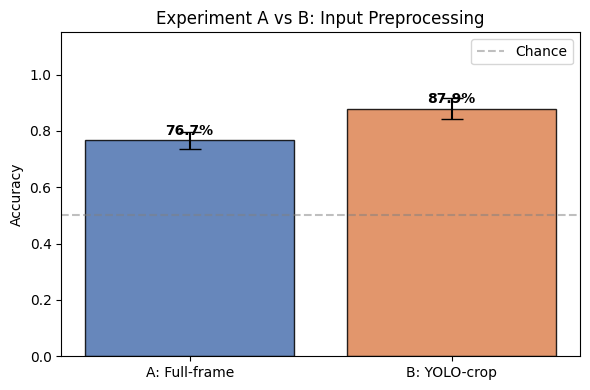

In [10]:
mean_A = np.mean(accs_A)
mean_B = np.mean(accs_B)

comparison_ab = pd.DataFrame({
    "Experiment": ["A: Full-frame", "B: YOLO-crop"],
    "Mean Accuracy": [f"{mean_A:.1%}", f"{mean_B:.1%}"],
    "Std": [f"{np.std(accs_A):.1%}", f"{np.std(accs_B):.1%}"],
    "Per-Fold": [str([f'{a:.1%}' for a in accs_A]), str([f'{a:.1%}' for a in accs_B])],
    "Time (s)": [f"{time_A:.0f}", f"{time_B:.0f}"],
})
print(comparison_ab.to_string(index=False))

if mean_B > mean_A:
    WINNER_INPUT = "crop"
    winner_factory = make_cropped_dataset
    winner_factory_aug = make_cropped_dataset_aug
    winner_reps = reps_with_kps
    winner_name = "B: YOLO-crop"
    winner_accs = accs_B
    winner_results = results_B
    winner_time = time_B
else:
    WINNER_INPUT = "full"
    winner_factory = make_full_frame_dataset
    winner_factory_aug = make_full_frame_dataset_aug
    winner_reps = rep_segments
    winner_name = "A: Full-frame"
    winner_accs = accs_A
    winner_results = results_A
    winner_time = time_A

print(f"\nWinner: {winner_name} ({np.mean(winner_accs):.1%})")
print(f"Proceeding with {WINNER_INPUT} input for unfreezing experiments.")

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ["A: Full-frame", "B: YOLO-crop"],
    [mean_A, mean_B],
    yerr=[np.std(accs_A), np.std(accs_B)],
    capsize=8, color=["#4C72B0", "#DD8452"], alpha=0.85, edgecolor="black",
)
for bar, m in zip(bars, [mean_A, mean_B]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{m:.1%}", ha="center", fontweight="bold")
ax.set_ylabel("Accuracy")
ax.set_title("Experiment A vs B: Input Preprocessing")
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Chance")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ab_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Unfreezing Experiment

Using the winning input preprocessing, compare:
- **Frozen**: Only FC head trainable (baseline — already done above)
- **Unfreeze 1 block**: layer4 + FC trainable
- **Unfreeze 2 blocks**: layer3 + layer4 + FC trainable

In [11]:
unfreeze_results = {}

# Already have frozen results from the winner
unfreeze_results["frozen"] = {
    "accs": winner_accs,
    "results": winner_results,
    "time": winner_time,
    "params": make_model_frozen().trainable_param_count(),
}

for n_blocks in [1, 2]:
    def make_model_unfrozen(n=n_blocks):
        m = PushUpR3D(freeze_backbone=True)
        m.unfreeze_last_n_blocks(n)
        return m

    n_params = make_model_unfrozen().trainable_param_count()
    label = f"unfreeze_{n_blocks}"
    print(f"\n{'='*60}")
    print(f"Unfreeze {n_blocks} block(s): {n_params:,} trainable params")
    print(f"{'='*60}")

    t0 = time.time()
    res = run_rep_kfold_cv(
        model_factory=make_model_unfrozen,
        dataset_factory=winner_factory,
        rep_segments=winner_reps,
        n_splits=N_SPLITS,
        n_epochs=30,
        batch_size=8,
        lr=1e-4,    # lower LR for fine-tuning unfrozen layers
        patience=10,
        device_str=DEVICE,
        random_state=RANDOM_STATE,
        train_dataset_factory=winner_factory_aug,
    )
    elapsed = time.time() - t0

    accs = [f["val_accuracy"] for f in res["fold_results"]]
    print(f"  Per-fold: {[f'{a:.1%}' for a in accs]}")
    print(f"  Mean: {np.mean(accs):.1%} +/- {np.std(accs):.1%}")
    print(f"  Time: {elapsed:.0f}s")

    unfreeze_results[label] = {
        "accs": accs,
        "results": res,
        "time": elapsed,
        "params": n_params,
    }

INFO: Fold 0: train=218 reps (161 vids), val=53 reps (41 vids)



Unfreeze 1 block(s): 24,909,826 trainable params
  Fold 0 | Epoch 01/30 | train_loss=0.4764 | val_loss=0.2376 | val_acc=88.7% *
  Fold 0 | Epoch 02/30 | train_loss=0.1850 | val_loss=0.1256 | val_acc=96.2% *
  Fold 0 | Epoch 03/30 | train_loss=0.1463 | val_loss=0.1162 | val_acc=96.2%
  Fold 0 | Epoch 04/30 | train_loss=0.0983 | val_loss=0.1169 | val_acc=96.2%
  Fold 0 | Epoch 05/30 | train_loss=0.0515 | val_loss=0.1038 | val_acc=96.2%
  Fold 0 | Epoch 06/30 | train_loss=0.0276 | val_loss=0.0828 | val_acc=96.2%
  Fold 0 | Epoch 07/30 | train_loss=0.0892 | val_loss=0.1755 | val_acc=92.5%
  Fold 0 | Epoch 08/30 | train_loss=0.0860 | val_loss=0.1861 | val_acc=94.3%
  Fold 0 | Epoch 09/30 | train_loss=0.0984 | val_loss=0.1514 | val_acc=94.3%
  Fold 0 | Epoch 10/30 | train_loss=0.1593 | val_loss=0.2323 | val_acc=94.3%
  Fold 0 | Epoch 11/30 | train_loss=0.0927 | val_loss=0.1212 | val_acc=96.2%


INFO: Fold 0: early stopping at epoch 11 (best_acc=0.9623)


  Fold 0 | Epoch 12/30 | train_loss=0.0723 | val_loss=0.1256 | val_acc=96.2%


INFO: Fold 0: val_accuracy=0.9623
INFO: Fold 1: train=213 reps (161 vids), val=58 reps (41 vids)


...

  Fold 4 | Epoch 01/30 | train_loss=0.4634 | val_loss=0.1010 | val_acc=100.0% *
  Fold 4 | Epoch 02/30 | train_loss=0.1906 | val_loss=0.0969 | val_acc=96.2%
  Fold 4 | Epoch 03/30 | train_loss=0.0816 | val_loss=0.1000 | val_acc=94.2%
  Fold 4 | Epoch 04/30 | train_loss=0.0928 | val_loss=0.0698 | val_acc=100.0%
  Fold 4 | Epoch 05/30 | train_loss=0.0597 | val_loss=0.0296 | val_acc=100.0%
  Fold 4 | Epoch 06/30 | train_loss=0.1237 | val_loss=0.0231 | val_acc=100.0%
  Fold 4 | Epoch 07/30 | train_loss=0.1865 | val_loss=0.0144 | val_acc=100.0%
  Fold 4 | Epoch 08/30 | train_loss=0.0673 | val_loss=0.0342 | val_acc=100.0%
  Fold 4 | Epoch 09/30 | train_loss=0.1061 | val_loss=0.1771 | val_acc=92.3%
  Fold 4 | Epoch 10/30 | train_loss=0.0329 | val_loss=0.1097 | val_acc=94.2%


INFO: Fold 4: early stopping at epoch 10 (best_acc=1.0000)


  Fold 4 | Epoch 11/30 | train_loss=0.0408 | val_loss=0.0286 | val_acc=100.0%


INFO: Fold 4: val_accuracy=1.0000


  Per-fold: ['96.2%', '98.3%', '98.1%', '92.6%', '100.0%']
  Mean: 97.0% +/- 2.5%
  Time: 510s


                      Config Trainable Params Mean Accuracy  Std Time (s)
            Frozen (FC only)            1,026         87.9% 3.8%      946
   Unfreeze 1 block (layer4)       24,909,826         97.4% 3.6%      483
Unfreeze 2 blocks (layer3+4)       31,138,306         97.0% 2.5%      510


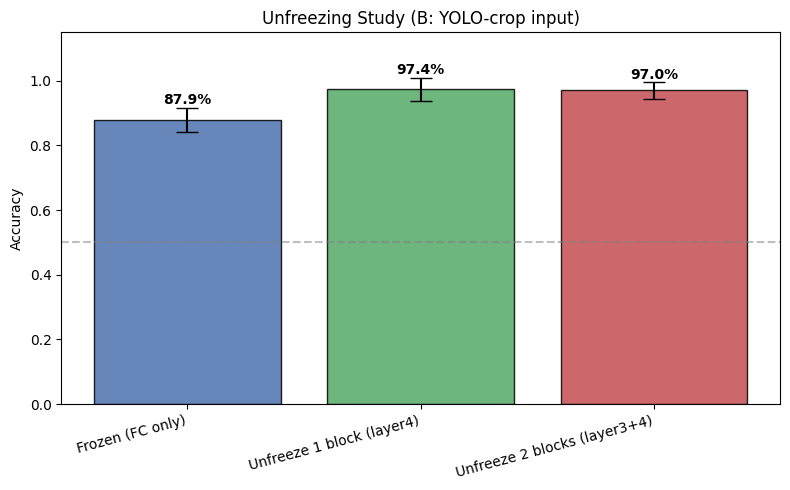


Best unfreezing config: unfreeze_1 (97.4%)


In [12]:
# Unfreezing comparison table
unfreeze_labels = ["frozen", "unfreeze_1", "unfreeze_2"]
display_names = ["Frozen (FC only)", "Unfreeze 1 block (layer4)", "Unfreeze 2 blocks (layer3+4)"]

unfreeze_df = pd.DataFrame({
    "Config": display_names,
    "Trainable Params": [f"{unfreeze_results[k]['params']:,}" for k in unfreeze_labels],
    "Mean Accuracy": [f"{np.mean(unfreeze_results[k]['accs']):.1%}" for k in unfreeze_labels],
    "Std": [f"{np.std(unfreeze_results[k]['accs']):.1%}" for k in unfreeze_labels],
    "Time (s)": [f"{unfreeze_results[k]['time']:.0f}" for k in unfreeze_labels],
})
print(unfreeze_df.to_string(index=False))

# Bar chart
means_u = [np.mean(unfreeze_results[k]["accs"]) for k in unfreeze_labels]
stds_u = [np.std(unfreeze_results[k]["accs"]) for k in unfreeze_labels]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#4C72B0", "#55A868", "#C44E52"]
bars = ax.bar(display_names, means_u, yerr=stds_u, capsize=8,
              color=colors, alpha=0.85, edgecolor="black")
for bar, m, s in zip(bars, means_u, stds_u):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.01,
            f"{m:.1%}", ha="center", fontweight="bold")
ax.set_ylabel("Accuracy")
ax.set_title(f"Unfreezing Study ({winner_name} input)")
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "unfreeze_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Pick best unfreezing config
best_unfreeze = max(unfreeze_labels, key=lambda k: np.mean(unfreeze_results[k]["accs"]))
best_unfreeze_acc = np.mean(unfreeze_results[best_unfreeze]["accs"])
print(f"\nBest unfreezing config: {best_unfreeze} ({best_unfreeze_acc:.1%})")

---
## Hyperparameter Tuning

Grid search over learning rate and batch size using the best config from above.

In [13]:
# Determine the best model factory based on unfreezing results
def _make_best_model():
    m = PushUpR3D(freeze_backbone=True)
    if best_unfreeze == "unfreeze_1":
        m.unfreeze_last_n_blocks(1)
    elif best_unfreeze == "unfreeze_2":
        m.unfreeze_last_n_blocks(2)
    return m

print(f"Tuning config: {best_unfreeze} + {WINNER_INPUT} input")
print(f"  Trainable params: {_make_best_model().trainable_param_count():,}")

# Hyperparameter grid
LR_OPTIONS = [1e-4, 5e-4, 1e-3]
BS_OPTIONS = [4, 8, 16]

hp_results = []

for lr in LR_OPTIONS:
    for bs in BS_OPTIONS:
        print(f"\n--- lr={lr}, batch_size={bs} ---")
        t0 = time.time()
        res = run_rep_kfold_cv(
            model_factory=_make_best_model,
            dataset_factory=winner_factory,
            rep_segments=winner_reps,
            n_splits=N_SPLITS,
            n_epochs=30,
            batch_size=bs,
            lr=lr,
            patience=10,
            device_str=DEVICE,
            random_state=RANDOM_STATE,
            train_dataset_factory=winner_factory_aug,
        )
        elapsed = time.time() - t0
        accs = [f["val_accuracy"] for f in res["fold_results"]]
        mean_acc = np.mean(accs)
        std_acc = np.std(accs)
        print(f"  Mean: {mean_acc:.1%} +/- {std_acc:.1%} ({elapsed:.0f}s)")

        hp_results.append({
            "lr": lr,
            "batch_size": bs,
            "mean_acc": mean_acc,
            "std_acc": std_acc,
            "per_fold": accs,
            "time": elapsed,
            "results": res,
        })

Tuning config: unfreeze_1 + crop input


INFO: Fold 0: train=218 reps (161 vids), val=53 reps (41 vids)


  Trainable params: 24,909,826

--- lr=0.0001, batch_size=4 ---
  Fold 0 | Epoch 01/30 | train_loss=0.5435 | val_loss=0.3092 | val_acc=81.1% *
  Fold 0 | Epoch 02/30 | train_loss=0.2713 | val_loss=0.2121 | val_acc=90.6% *
  Fold 0 | Epoch 03/30 | train_loss=0.2360 | val_loss=0.2111 | val_acc=94.3% *
  Fold 0 | Epoch 04/30 | train_loss=0.2996 | val_loss=0.2068 | val_acc=92.5%
  Fold 0 | Epoch 05/30 | train_loss=0.2380 | val_loss=0.2140 | val_acc=92.5%
  Fold 0 | Epoch 06/30 | train_loss=0.2184 | val_loss=0.0961 | val_acc=94.3%
  Fold 0 | Epoch 07/30 | train_loss=0.1690 | val_loss=0.0906 | val_acc=94.3%
  Fold 0 | Epoch 08/30 | train_loss=0.0934 | val_loss=0.0845 | val_acc=96.2% *
  Fold 0 | Epoch 09/30 | train_loss=0.1797 | val_loss=0.1691 | val_acc=90.6%
  Fold 0 | Epoch 10/30 | train_loss=0.1833 | val_loss=0.0982 | val_acc=96.2%
  Fold 0 | Epoch 11/30 | train_loss=0.2690 | val_loss=0.1275 | val_acc=92.5%
  Fold 0 | Epoch 12/30 | train_loss=0.2091 | val_loss=0.0876 | val_acc=96.2%
  Fo

INFO: Fold 0: early stopping at epoch 24 (best_acc=0.9811)


  Fold 0 | Epoch 25/30 | train_loss=0.0366 | val_loss=0.0989 | val_acc=96.2%


...

  Fold 4 | Epoch 01/30 | train_loss=0.7319 | val_loss=1.7119 | val_acc=71.2% *
  Fold 4 | Epoch 02/30 | train_loss=0.2898 | val_loss=0.2064 | val_acc=92.3% *
  Fold 4 | Epoch 03/30 | train_loss=0.1264 | val_loss=0.0777 | val_acc=98.1% *
  Fold 4 | Epoch 04/30 | train_loss=0.1007 | val_loss=0.0320 | val_acc=100.0% *
  Fold 4 | Epoch 05/30 | train_loss=0.0496 | val_loss=0.1543 | val_acc=96.2%
  Fold 4 | Epoch 06/30 | train_loss=0.0321 | val_loss=0.0569 | val_acc=98.1%
  Fold 4 | Epoch 07/30 | train_loss=0.0261 | val_loss=0.0128 | val_acc=100.0%
  Fold 4 | Epoch 08/30 | train_loss=0.0324 | val_loss=0.0330 | val_acc=98.1%
  Fold 4 | Epoch 09/30 | train_loss=0.0403 | val_loss=0.1146 | val_acc=94.2%
  Fold 4 | Epoch 10/30 | train_loss=0.0244 | val_loss=0.0417 | val_acc=98.1%
  Fold 4 | Epoch 11/30 | train_loss=0.0599 | val_loss=0.1498 | val_acc=90.4%
  Fold 4 | Epoch 12/30 | train_loss=0.0516 | val_loss=0.1046 | val_acc=96.2%
  Fold 4 | Epoch 13/30 | train_loss=0.0249 | val_loss=0.0221 | val

INFO: Fold 4: early stopping at epoch 13 (best_acc=1.0000)


  Fold 4 | Epoch 14/30 | train_loss=0.0226 | val_loss=0.0108 | val_acc=100.0%


INFO: Fold 4: val_accuracy=1.0000


  Mean: 98.5% +/- 1.8% (644s)


   LR  Batch Size Mean Accuracy  Std Time (s)
1e-04           4         97.4% 3.4%      539
1e-04           8         97.4% 3.4%      561
1e-04          16         97.4% 3.4%      522
5e-04           4         98.1% 2.9%      544
5e-04           8         97.4% 3.4%      568
5e-04          16         97.1% 3.4%      571
1e-03           4         97.8% 3.0%      772
1e-03           8         97.4% 2.2%      578
1e-03          16         98.5% 1.8%      644


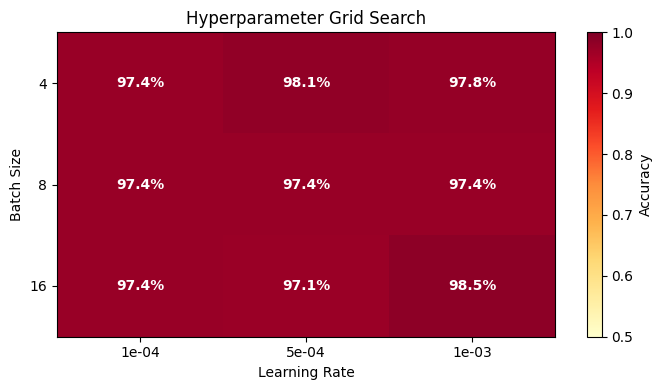


Best hyperparams: lr=1e-03, batch_size=16
  Accuracy: 98.5% +/- 1.8%


In [14]:
# Hyperparameter results table
hp_df = pd.DataFrame([
    {
        "LR": f"{r['lr']:.0e}",
        "Batch Size": r["batch_size"],
        "Mean Accuracy": f"{r['mean_acc']:.1%}",
        "Std": f"{r['std_acc']:.1%}",
        "Time (s)": f"{r['time']:.0f}",
    }
    for r in hp_results
])
print(hp_df.to_string(index=False))

# Heatmap
pivot = pd.DataFrame(hp_results).pivot(
    index="batch_size", columns="lr", values="mean_acc"
)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto", vmin=0.5, vmax=1.0)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{c:.0e}" for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Learning Rate")
ax.set_ylabel("Batch Size")
ax.set_title("Hyperparameter Grid Search")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.1%}", ha="center", va="center",
                fontweight="bold", color="white" if val > 0.75 else "black")

plt.colorbar(im, label="Accuracy")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "hp_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Best HP config
best_hp = max(hp_results, key=lambda r: r["mean_acc"])
print(f"\nBest hyperparams: lr={best_hp['lr']:.0e}, batch_size={best_hp['batch_size']}")
print(f"  Accuracy: {best_hp['mean_acc']:.1%} +/- {best_hp['std_acc']:.1%}")

---
## Final Comparison

Summary of all experiments in a single table and chart.

In [15]:
# Build final comparison
all_experiments = []

# A: full-frame frozen
all_experiments.append({
    "Experiment": "A: Full-frame (frozen)",
    "Input": "Full-frame",
    "Backbone": "Frozen",
    "Params": f"{make_model_frozen().trainable_param_count():,}",
    "LR": "1e-3",
    "Batch Size": 8,
    "Mean Acc": np.mean(accs_A),
    "Std": np.std(accs_A),
    "Time (s)": f"{time_A:.0f}",
})

# B: YOLO-crop frozen
all_experiments.append({
    "Experiment": "B: YOLO-crop (frozen)",
    "Input": "YOLO-crop",
    "Backbone": "Frozen",
    "Params": f"{make_model_frozen().trainable_param_count():,}",
    "LR": "1e-3",
    "Batch Size": 8,
    "Mean Acc": np.mean(accs_B),
    "Std": np.std(accs_B),
    "Time (s)": f"{time_B:.0f}",
})

# Unfreezing experiments
for label, display in [("unfreeze_1", "Unfreeze 1 block"), ("unfreeze_2", "Unfreeze 2 blocks")]:
    r = unfreeze_results[label]
    all_experiments.append({
        "Experiment": f"{display} ({WINNER_INPUT})",
        "Input": WINNER_INPUT.capitalize(),
        "Backbone": display,
        "Params": f"{r['params']:,}",
        "LR": "1e-4",
        "Batch Size": 8,
        "Mean Acc": np.mean(r["accs"]),
        "Std": np.std(r["accs"]),
        "Time (s)": f"{r['time']:.0f}",
    })

# Best HP
all_experiments.append({
    "Experiment": f"Best HP ({best_unfreeze}, {WINNER_INPUT})",
    "Input": WINNER_INPUT.capitalize(),
    "Backbone": best_unfreeze.replace("_", " ").title(),
    "Params": f"{_make_best_model().trainable_param_count():,}",
    "LR": f"{best_hp['lr']:.0e}",
    "Batch Size": best_hp["batch_size"],
    "Mean Acc": best_hp["mean_acc"],
    "Std": best_hp["std_acc"],
    "Time (s)": f"{best_hp['time']:.0f}",
})

final_df = pd.DataFrame(all_experiments)
print(final_df.to_string(index=False))

                Experiment      Input          Backbone     Params    LR  Batch Size  Mean Acc      Std Time (s)
    A: Full-frame (frozen) Full-frame            Frozen      1,026  1e-3           8  0.766756 0.030720      735
     B: YOLO-crop (frozen)  YOLO-crop            Frozen      1,026  1e-3           8  0.878832 0.037991      946
   Unfreeze 1 block (crop)       Crop  Unfreeze 1 block 24,909,826  1e-4           8  0.973934 0.036333      483
  Unfreeze 2 blocks (crop)       Crop Unfreeze 2 blocks 31,138,306  1e-4           8  0.970486 0.025282      510
Best HP (unfreeze_1, crop)       Crop        Unfreeze 1 24,909,826 1e-03          16  0.985045 0.018317      644


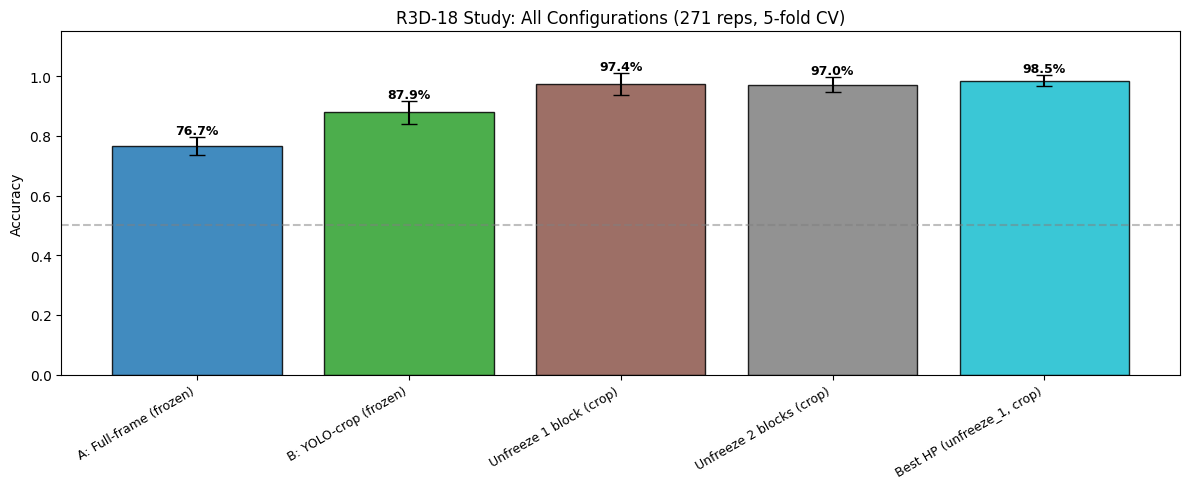


Best overall: Best HP (unfreeze_1, crop)
  Accuracy: 98.5% +/- 1.8%
  Config: 24,909,826 params, lr=1e-03, bs=16


In [16]:
# Final bar chart
names = final_df["Experiment"].tolist()
means_f = final_df["Mean Acc"].tolist()
stds_f = final_df["Std"].tolist()

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(names)))
bars = ax.bar(range(len(names)), means_f, yerr=stds_f, capsize=6,
              color=colors, alpha=0.85, edgecolor="black")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha="right", fontsize=9)

for bar, m, s in zip(bars, means_f, stds_f):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.01,
            f"{m:.1%}", ha="center", fontweight="bold", fontsize=9)

ax.set_ylabel("Accuracy")
ax.set_title(f"R3D-18 Study: All Configurations ({len(rep_segments)} reps, {N_SPLITS}-fold CV)")
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Highlight best
best_row = final_df.loc[final_df["Mean Acc"].idxmax()]
print(f"\nBest overall: {best_row['Experiment']}")
print(f"  Accuracy: {best_row['Mean Acc']:.1%} +/- {best_row['Std']:.1%}")
print(f"  Config: {best_row['Params']} params, lr={best_row['LR']}, bs={best_row['Batch Size']}")

---
## Overfitting Analysis

Three checks:
1. **Train vs val loss curves** — diverging curves = overfitting
2. **Confusion matrix** — is the model biased toward one class?
3. **Per-video error analysis** — are errors spread across videos or concentrated?

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# ---- 1. Train vs Val Loss Curves ----
# Compare frozen (B) vs best unfrozen to see overfitting gap

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs_to_plot = [
    ("B: YOLO-crop (frozen)", results_B),
    (f"Unfreeze 1 block (crop)", unfreeze_results["unfreeze_1"]["results"]),
    (f"Best HP", best_hp["results"]),
]

for ax, (name, res) in zip(axes, configs_to_plot):
    for fold_res in res["fold_results"]:
        if "epoch_train_losses" not in fold_res:
            ax.set_title(f"{name}\n(no epoch history — rerun needed)")
            continue
        epochs = range(1, len(fold_res["epoch_train_losses"]) + 1)
        ax.plot(epochs, fold_res["epoch_train_losses"], "b-", alpha=0.3)
        ax.plot(epochs, fold_res["epoch_val_losses"], "r-", alpha=0.3)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"{name}")
    ax.legend(["Train", "Val"], loc="upper right")

plt.suptitle("Train vs Val Loss (blue=train, red=val) — each line is one fold", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "overfitting_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ---- 2. Confusion Matrices ----
# Compare frozen vs best unfrozen predictions

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configs_cm = [
    ("A: Full-frame (frozen)", results_A),
    ("B: YOLO-crop (frozen)", results_B),
    ("Best HP (unfrozen)", best_hp["results"]),
]

for ax, (name, res) in zip(axes, configs_cm):
    preds = res["per_rep_preds"]
    true = res["per_rep_true"]
    # Filter out None predictions (shouldn't happen but just in case)
    valid = [(p, t) for p, t in zip(preds, true) if p is not None]
    if not valid:
        continue
    p, t = zip(*valid)
    cm = confusion_matrix(t, p, labels=[0, 1])

    im = ax.imshow(cm, cmap="Blues", interpolation="nearest")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Good", "Bad"])
    ax.set_yticklabels(["Good", "Bad"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(name)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=16, fontweight="bold",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.suptitle("Confusion Matrices — per-rep CV predictions", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# Print classification reports
for name, res in configs_cm:
    preds = [p for p in res["per_rep_preds"] if p is not None]
    true = [t for p, t in zip(res["per_rep_preds"], res["per_rep_true"]) if p is not None]
    print(f"\n{name}:")
    print(classification_report(true, preds, target_names=["Good", "Bad"]))

In [ ]:
# ---- 3. Per-Video Error Analysis (Best HP model) ----
# Check if errors are spread across videos or concentrated on specific ones

best_preds = best_hp["results"]["per_rep_preds"]
best_true = best_hp["results"]["per_rep_true"]

# Use the reps that match the winner (crop = reps_with_kps, full = rep_segments)
analysis_reps = winner_reps

video_stats = {}
for i, rep in enumerate(analysis_reps):
    vid = rep["video_id"]
    pred = best_preds[i]
    true = best_true[i]
    if pred is None:
        continue
    if vid not in video_stats:
        video_stats[vid] = {"correct": 0, "wrong": 0, "label": rep["label"]}
    if pred == true:
        video_stats[vid]["correct"] += 1
    else:
        video_stats[vid]["wrong"] += 1

# Videos with errors
error_videos = {k: v for k, v in video_stats.items() if v["wrong"] > 0}
perfect_videos = {k: v for k, v in video_stats.items() if v["wrong"] == 0}

print(f"Total videos: {len(video_stats)}")
print(f"Perfect (0 errors): {len(perfect_videos)}")
print(f"With errors: {len(error_videos)}")

if error_videos:
    print(f"\nVideos with misclassified reps:")
    print(f"{'Video':<35} {'Label':<8} {'Correct':<10} {'Wrong':<8}")
    print("-" * 65)
    for vid, stats in sorted(error_videos.items(), key=lambda x: -x[1]["wrong"]):
        label = "Good" if stats["label"] == 0 else "Bad"
        print(f"{vid:<35} {label:<8} {stats['correct']:<10} {stats['wrong']:<8}")

# Check: are errors biased toward good or bad?
good_errors = sum(v["wrong"] for v in error_videos.values() if v["label"] == 0)
bad_errors = sum(v["wrong"] for v in error_videos.values() if v["label"] == 1)
print(f"\nMisclassified reps from 'good' videos: {good_errors}")
print(f"Misclassified reps from 'bad' videos: {bad_errors}")

plt.figure(figsize=(8, 4))
error_counts = [v["wrong"] for v in video_stats.values()]
plt.hist(error_counts, bins=range(max(error_counts) + 2), edgecolor="black", alpha=0.7)
plt.xlabel("Number of misclassified reps per video")
plt.ylabel("Number of videos")
plt.title("Error Distribution Across Videos (Best HP model)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "error_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Save Results

In [17]:
# Save summary CSV
final_df.to_csv(OUTPUT_DIR / "r3d_study_results.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'r3d_study_results.csv'}")

# Save HP grid CSV
hp_df.to_csv(OUTPUT_DIR / "r3d_hp_grid.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'r3d_hp_grid.csv'}")

# Save best model weights
if best_hp["results"]["best_state"] is not None:
    torch.save(best_hp["results"]["best_state"], OUTPUT_DIR / "r3d_best.pt")
    print(f"Saved: {OUTPUT_DIR / 'r3d_best.pt'}")

print(f"\nAll outputs saved to: {OUTPUT_DIR.resolve()}")
print("\nFigures:")
for f in sorted(OUTPUT_DIR.glob("*.png")):
    print(f"  {f.name}")
print("CSVs:")
for f in sorted(OUTPUT_DIR.glob("*.csv")):
    print(f"  {f.name}")

Saved: outputs/r3d_study_results.csv
Saved: outputs/r3d_hp_grid.csv
Saved: outputs/r3d_best.pt

All outputs saved to: /workspace/pushup-tracker/r3d_study/outputs

Figures:
  ab_comparison.png
  final_comparison.png
  hp_heatmap.png
  unfreeze_comparison.png
CSVs:
  r3d_hp_grid.csv
  r3d_study_results.csv
